In [ ]:
# 코랩 환경 필수 패키지 설치 (맨 앞에 느낌표 필수)
!pip install timm

In [ ]:
!pip install onnx onnx2tf tensorflow -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 223.2/223.2 kB 6.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 42.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.5/17.5 MB 72.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.3/16.3 MB 75.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 58.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.7/4.7 MB 47.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 49.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.2/17.2 MB 46.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 689.1/689.1 kB 33.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 45.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.0/63.0 MB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 294.6/294.6 kB

In [ ]:
# 구글 드라이브와 코랩 서버 연결
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp -r /content/drive/MyDrive/zds/dataset.zip /content/

# 코랩 로컬 압축 풀기
!unzip -qo /content/dataset.zip -d /content/

In [ ]:
# 1. import 및 시드 고정
import os
import time
import gc
import random
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image
import timm
from tqdm.auto import tqdm
from sklearn.metrics import average_precision_score, f1_score, average_precision_score, f1_score, accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt
import onnx
import tensorflow as tf
from onnx2tf import convert
import pandas as pd
import shutil

# 디바이스를 CUDA로 강제 고정
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

seed_everything(42)
print(f"✅ 1. 디바이스: {DEVICE} | 모든 난수(Seed) 42번으로 고정 완료")

✅ 1. 디바이스: cuda | 모든 난수(Seed) 42번으로 고정 완료


In [ ]:
# 2. 데이터셋 및 공통 전처리
TRAIN_IMG_DIR = '/content/dataset/train_img'
TEST_IMG_DIR = '/content/dataset/test_img'
TRAIN_LABEL_FILE = '/content/dataset/train_label.txt'
TEST_LABEL_FILE = '/content/dataset/test_label.txt'

class CompositionDataset(Dataset):
    def __init__(self, img_dir, label_file, transform=None):
        self.img_dir = img_dir
        self.transform = transform
        self.img_id_list = []
        self.ext_mapping = {}
        self.labels = {}

        with open(label_file, 'r') as f:
            for i, line in enumerate(f):
                img_id = f"{i+1:04d}"
                label_values = [float(x) for x in line.strip().split()]
                self.labels[img_id] = torch.tensor(label_values)

        valid_extensions = ('.jpg', '.jpeg', '.png')
        if os.path.exists(img_dir):
            all_files = [f for f in os.listdir(img_dir) if f.lower().endswith(valid_extensions)]
            for f_name in all_files:
                file_id, ext = os.path.splitext(f_name)
                if file_id in self.labels:
                    self.img_id_list.append(file_id)
                    self.ext_mapping[file_id] = ext

        self.img_id_list.sort()
        print(f"📂 폴더: {img_dir} | 라벨 매칭 이미지 수: {len(self.img_id_list)}")

    def __len__(self):
        return len(self.img_id_list)

    def __getitem__(self, idx):
        img_id = self.img_id_list[idx]
        ext = self.ext_mapping[img_id]
        f_name = img_id + ext

        image = Image.open(os.path.join(self.img_dir, f_name)).convert('RGB')
        label = self.labels[img_id]

        if self.transform:
            image = self.transform(image)

        return image, label

# 전 세계 표준 이미지 해상도 및 ImageNet 정규화 고정 (통제 변인)
data_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# 1. 데이터셋 로드 및 로더 빌드
train_dataset = CompositionDataset(TRAIN_IMG_DIR, TRAIN_LABEL_FILE, transform=data_transform)
val_dataset = CompositionDataset(TEST_IMG_DIR, TEST_LABEL_FILE, transform=data_transform)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=2, pin_memory=True, persistent_workers=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=2, pin_memory=True, persistent_workers=True)

print("✅ 2. 데이터 파이프라인 빌드 완료")

📂 폴더: /content/dataset/train_img | 라벨 매칭 이미지 수: 3169
📂 폴더: /content/dataset/test_img | 라벨 매칭 이미지 수: 1082
✅ 2. 데이터 파이프라인 빌드 완료


In [ ]:
# 3. 공통 학습 루프 및 시각화
def train_model_with_metrics(model, train_loader, val_loader, criterion, optimizer, num_epochs=100, patience=10):
    model.to(DEVICE)

    print("\n🔥 GPU Warm-up 진행 중...")
    model.train()
    dummy_input = torch.randn(32, 3, 224, 224).to(DEVICE)
    for _ in range(3):
        _ = model(dummy_input)
    torch.cuda.synchronize()
    print("✅ Warm-up 완료\n")

    history = {
        'train_loss': [], 'val_loss': [],
        'train_accuracy': [], 'val_accuracy': [],
        'val_mAP': [], 'val_macro_f1': [], 'val_micro_f1': [],
        'val_precision': [], 'val_recall': [],
        'epoch_time': []
    }

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None
    total_train_images = len(train_loader.dataset)

    for epoch in range(num_epochs):
        torch.cuda.synchronize()
        epoch_start_time = time.time()

        # ==================== [1] 학습 단계 ====================
        model.train()
        train_loss = 0.0
        train_all_targets = []
        train_all_outputs = []

        for images, labels in tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]"):
            images, labels = images.to(DEVICE), labels.to(DEVICE).float()
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * images.size(0)

            # 🌟 Train Accuracy 데이터 수집
            train_all_targets.append(labels.cpu().numpy())
            train_all_outputs.append(outputs.detach().cpu().numpy())

        # ==================== [2] 검증 단계 ====================
        model.eval()
        val_loss = 0.0
        all_targets = []
        all_outputs = []

        with torch.no_grad():
            for images, labels in tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]"):
                images, labels = images.to(DEVICE), labels.to(DEVICE).float()
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * images.size(0)

                all_targets.append(labels.cpu().numpy())
                all_outputs.append(outputs.cpu().numpy())

        torch.cuda.synchronize()
        epoch_end_time = time.time()

        pure_epoch_duration = epoch_end_time - epoch_start_time

        epoch_train_loss = train_loss / total_train_images
        epoch_val_loss = val_loss / len(val_loader.dataset)

        # ==================== [3] 다중 라벨 성능 점수 연산 ====================
        # 🌟 Train 데이터셋 정확도 계산
        y_train_true = np.vstack(train_all_targets)
        y_train_scores = np.vstack(train_all_outputs)
        y_train_pred = (y_train_scores >= 0.0).astype(int)
        epoch_train_accuracy = accuracy_score(y_train_true, y_train_pred)

        # Val 데이터셋 지표 계산
        y_true = np.vstack(all_targets)
        y_scores = np.vstack(all_outputs)
        y_pred = (y_scores >= 0.0).astype(int)

        val_mAP = average_precision_score(y_true, y_scores, average='macro')
        val_macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        val_micro_f1 = f1_score(y_true, y_pred, average='micro', zero_division=0)

        val_accuracy = accuracy_score(y_true, y_pred)
        val_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        val_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)

        # 🌟 역사 기록 보관소에 데이터 누적
        history['train_loss'].append(epoch_train_loss)
        history['val_loss'].append(epoch_val_loss)
        history['train_accuracy'].append(epoch_train_accuracy)
        history['val_accuracy'].append(val_accuracy)
        history['val_mAP'].append(val_mAP)
        history['val_macro_f1'].append(val_macro_f1)
        history['val_micro_f1'].append(val_micro_f1)
        history['val_precision'].append(val_precision)
        history['val_recall'].append(val_recall)
        history['epoch_time'].append(pure_epoch_duration)

        print(f"\n▶️ [Epoch {epoch+1} 결산]")
        print(f"  - Loss       | Train Loss: {epoch_train_loss:.4f}  /  Val Loss: {epoch_val_loss:.4f}")
        print(f"  - Accuracy   | 🌟 Train Acc: {epoch_train_accuracy:.4f}  /  Val Acc: {val_accuracy:.4f}")
        print(f"  - Metrics    | mAP: {val_mAP*100:.2f}%  /  Macro F1: {val_macro_f1:.4f}  /  Prec: {val_precision:.4f}  /  Rec: {val_recall:.4f}")
        print(f"  - Hardware   | ⏱️ 소요 시간: {pure_epoch_duration:.2f}초")

        # ==================== [4] EARLY STOPPING ====================
        if epoch_val_loss < best_val_loss:
            best_val_loss = epoch_val_loss
            patience_counter = 0
            best_model_state = model.state_dict()
            print(f"✨ 모델 갱신 (최저 Val Loss: {best_val_loss:.4f})")
        else:
            patience_counter += 1
            print(f"⚠️ 과적합 경고: {patience_counter} / {patience}")

        if patience_counter >= patience:
            print(f"🛑 {patience}회 연속 성능 개선 실패로 조기 종료")
            break
        print("-" * 80)

    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print("\n🏆 최적의 가중치 복원 완료")

    best_idx = history['val_loss'].index(best_val_loss)
    avg_time = sum(history['epoch_time']) / len(history['epoch_time'])

    print(f"\n📊 실험 최종 결과")
    print(f"  - 에포크당 평균 순수 연산 시간: {avg_time:.2f}초")
    print(f"  - 최고 검증성능 최고점 (최저 Val Loss 시점) ➔ mAP: {history['val_mAP'][best_idx]*100:.2f}%")
    print(f"  - 🌟 최고점 시점 상세 지표 ➔ Accuracy: {history['val_accuracy'][best_idx]:.4f} | Macro F1: {history['val_macro_f1'][best_idx]:.4f} | Precision: {history['val_precision'][best_idx]:.4f} | Recall: {history['val_recall'][best_idx]:.4f}")

    return history

def plot_experiment_results(history, model_name, val_loader, model, device):

    # ✂️ 1. 조기 종료(Early Stopping) 발동 시 과적합 10개 에포크 컷 분기
    patience = 10
    total_run_epochs = len(history['train_loss'])

    if total_run_epochs > patience and history['val_loss'][-1] > min(history['val_loss']):
        clean_train_loss = history['train_loss'][:-patience]
        clean_val_loss = history['val_loss'][:-patience]
        clean_train_acc = history.get('train_accuracy', [])[:-patience]
        clean_val_acc = history.get('val_accuracy', [])[:-patience]
    else:
        clean_train_loss = history['train_loss']
        clean_val_loss = history['val_loss']
        clean_train_acc = history.get('train_accuracy', [])
        clean_val_acc = history.get('val_accuracy', [])

    epochs_range = range(1, len(clean_train_loss) + 1)

    # 📈 2. 그래프 시각화 (좌: Loss 추이 / 우: Accuracy 추이)
    plt.figure(figsize=(14, 5))

    # [좌측 그래프] Loss 추이
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, clean_train_loss, label='Train Loss', color='royalblue', marker='o', markersize=4)
    plt.plot(epochs_range, clean_val_loss, label='Val Loss', color='orange', marker='o', markersize=4)
    plt.xlabel('Epochs', fontsize=10)
    plt.ylabel('Loss', fontsize=10)
    plt.ylim(0.0, 1.0)
    plt.yticks(np.arange(0.0, 1.1, 0.1))
    plt.xticks(np.arange(1, len(clean_train_loss) + 1, 1))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    # [우측 그래프] Accuracy 추이
    plt.subplot(1, 2, 2)
    if clean_train_acc:
        plt.plot(epochs_range, clean_train_acc, label='Train Accuracy', color='mediumpurple', marker='o', markersize=4)
    if clean_val_acc:
        plt.plot(epochs_range, clean_val_acc, label='Val Accuracy', color='purple', marker='^', markersize=4)
    plt.xlabel('Epochs', fontsize=10)
    plt.ylabel('Accuracy', fontsize=10)
    plt.ylim(0.0, 1.0)
    plt.yticks(np.arange(0.0, 1.1, 0.1))
    plt.xticks(np.arange(1, len(clean_train_loss) + 1, 1))
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.legend()

    plt.tight_layout()
    plt.show()

    # 📊 3. 클래스별 최종 [Support 비율 & 실제 정답 기준 신뢰도] 대조표 출력
    print(f"📊 [{model_name} 최종 결산] 클래스별 Support 비율 및 실제 정답 기준 신뢰도 대조표")
    print("=" * 85)

    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            outputs = model(images)
            preds = torch.sigmoid(outputs)

            all_labels.append(labels.cpu())
            all_preds.append(preds.cpu())

    all_labels = torch.cat(all_labels).numpy()
    all_preds = torch.cat(all_preds).numpy()

    total_val_samples = all_labels.shape[0]
    num_classes = all_labels.shape[1]

    results = []
    for i in range(num_classes):
        true_indices = np.where(all_labels[:, i] == 1)[0]
        support_count = len(true_indices)
        support_ratio = (support_count / total_val_samples) * 100

        if support_count > 0:
            avg_confidence = np.mean(all_preds[true_indices, i]) * 100
        else:
            avg_confidence = 0.0

        results.append({
            "Class": f"Class {i}",
            "Support Ratio (정답 데이터 비율)": f"{support_ratio:.2f} %",
            "True Avg Confidence (정답 기준 신뢰도)": f"{avg_confidence:.2f} %"
        })

    df_report = pd.DataFrame(results)
    print(df_report.to_string(index=False))
    print("=" * 85 + "\n")

print("✅ 3. 공통 학습 루프 엔진 탑재 완료")

✅ 3. 공통 학습 루프 엔진 탑재 완료


🚀 tf_efficientnet_lite0 모델

🔥 GPU Warm-up 진행 중...
✅ Warm-up 완료



Epoch 1 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/34 [00:00<?, ?it/s]


▶️ [Epoch 1 결산]
  - Loss       | Train Loss: 0.5374  /  Val Loss: 0.3018
  - Accuracy   | 🌟 Train Acc: 0.1597  /  Val Acc: 0.2957
  - Metrics    | mAP: 56.67%  /  Macro F1: 0.5172  /  Prec: 0.5158  /  Rec: 0.5422
  - Hardware   | ⏱️ 소요 시간: 50.06초
✨ 모델 갱신 (최저 Val Loss: 0.3018)
--------------------------------------------------------------------------------


Epoch 2 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

...

Epoch 19 [Val]:   0%|          | 0/34 [00:00<?, ?it/s]


▶️ [Epoch 19 결산]
  - Loss       | Train Loss: 0.0092  /  Val Loss: 0.1793
  - Accuracy   | 🌟 Train Acc: 0.9883  /  Val Acc: 0.6266
  - Metrics    | mAP: 86.09%  /  Macro F1: 0.7886  /  Prec: 0.8255  /  Rec: 0.7646
  - Hardware   | ⏱️ 소요 시간: 48.93초
⚠️ 과적합 경고: 9 / 10
--------------------------------------------------------------------------------


Epoch 20 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20 [Val]:   0%|          | 0/34 [00:00<?, ?it/s]


▶️ [Epoch 20 결산]
  - Loss       | Train Loss: 0.0081  /  Val Loss: 0.1724
  - Accuracy   | 🌟 Train Acc: 0.9890  /  Val Acc: 0.6405
  - Metrics    | mAP: 86.91%  /  Macro F1: 0.7998  /  Prec: 0.8292  /  Rec: 0.7765
  - Hardware   | ⏱️ 소요 시간: 48.71초
⚠️ 과적합 경고: 10 / 10
🛑 10회 연속 성능 개선 실패로 조기 종료

🏆 최적의 가중치 복원 완료

📊 실험 최종 결과
  - 에포크당 평균 순수 연산 시간: 49.79초
  - 최고 검증성능 최고점 (최저 Val Loss 시점) ➔ mAP: 85.59%
  - 🌟 최고점 시점 상세 지표 ➔ Accuracy: 0.6322 | Macro F1: 0.7955 | Precision: 0.8260 | Recall: 0.7702


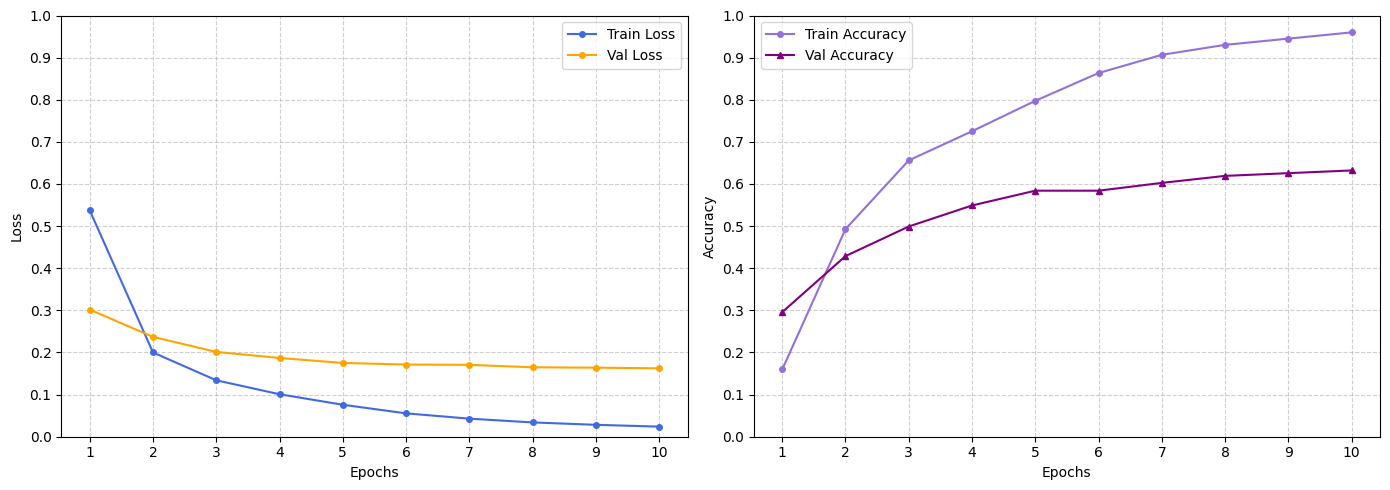

📊 [EfficientNet-Lite0 최종 결산] 클래스별 Support 비율 및 실제 정답 기준 신뢰도 대조표
  Class Support Ratio (정답 데이터 비율) True Avg Confidence (정답 기준 신뢰도)
Class 0                   11.55 %                         73.94 %
Class 1                    6.10 %                         75.19 %
Class 2                   19.50 %                         81.44 %
Class 3                   17.47 %                         63.36 %
Class 4                    8.50 %                         65.35 %
Class 5                   15.80 %                         77.30 %
Class 6                   28.74 %                         78.57 %
Class 7                    9.15 %                         76.78 %
Class 8                    5.82 %                         94.69 %

🔄 [1/3] PyTorch ➔ ONNX 규격 추출 중...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`...
[torch.onnx] Obtain model graph for `EfficientNet([...]` with `torch.export.export(..., strict=False)`... ✅
[torch.onnx] Run decomposit

/usr/lib/python3.12/copyreg.py:99: FutureWarning: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
  return cls.__new__(cls, *args)


[torch.onnx] Run decompositions... ✅
[torch.onnx] Translate the graph into ONNX...
[torch.onnx] Translate the graph into ONNX... ✅
[torch.onnx] Optimize the ONNX graph...
Applied 103 of general pattern rewrite rules.
[torch.onnx] Optimize the ONNX graph... ✅
✅ ONNX 파일 생성 완료.
🔄 [2/3] ONNX ➔ TensorFlow 번역 검사 중...


flatbuffer_direct lowering:   0%|          | 0/94 [00:00<?, ?it/s]

flatbuffer_direct post-lowering:   0%|          | 0/6 [00:00<?, ?it/s]

flatbuffer_direct export:   0%|          | 0/3 [00:00<?, ?it/s]

flatbuffer_direct write timing: stage=float32 mode=builder_direct total=0.076s serialize=0.065s (sanitize=0.000s build=0.008s pack=0.040s output=0.017s) write=0.011s size=12.84MB
flatbuffer_direct write timing: stage=float16 mode=builder_direct total=0.025s serialize=0.021s (sanitize=0.000s build=0.002s pack=0.018s output=0.001s) write=0.004s size=6.43MB
🔄 [3/3] 8비트 INT8 양자화 적용 및 TFLite 파일 생성 중...


OSError: SavedModel file does not exist at: tf_saved_model_eff/{saved_model.pbtxt|saved_model.pb}

In [ ]:
# 4. [실험 1] EfficientNet-Lite0 학습
num_classes = 9

print("🚀 tf_efficientnet_lite0 모델")
model_eff = timm.create_model('tf_efficientnet_lite0', pretrained=True, num_classes=num_classes)

criterion = nn.BCEWithLogitsLoss()
# 공정 변인 통제를 위한 AdamW 세팅 (lr=1e-4 고정)
optimizer_eff = optim.AdamW(model_eff.parameters(), lr=1e-4)

# 벤치마크 가동
history_eff = train_model_with_metrics(
    model_eff, train_loader, val_loader, criterion, optimizer_eff, num_epochs=100, patience=10
)

# 시각화
plot_experiment_results(history_eff, "EfficientNet-Lite0", val_loader, model_eff, DEVICE)

# ==============================================================================
# 🔥 파일 변환 (ONNX 파일 추출 단계 추가 및 경로 보완)
onnx_path = "efficientnet_lite0.onnx"
tflite_path = "efficientnet_lite0.tflite"

# 1. PyTorch ➔ ONNX 추출 (새 세션에서 파일 유실로 인한 에러 원천 차단)
print("🔄 [1/3] PyTorch ➔ ONNX 규격 추출 중...")
model_eff.eval()
dummy_input = torch.randn(1, 3, 224, 224).to(DEVICE)

torch.onnx.export(
    model_eff,
    dummy_input,
    onnx_path,
    export_params=True,
    opset_version=18,
    do_constant_folding=True,
    input_names=['input'],
    output_names=['output']
)
print("✅ ONNX 파일 생성 완료.")

# 2. ONNX ➔ TensorFlow 내부 구조 번역
print("🔄 [2/3] ONNX ➔ TensorFlow 번역 검사 중...")
# 변환이 꼬이지 않도록 기존 폴더가 있다면 밀고 재진행
if os.path.exists("tf_saved_model_eff"):
    shutil.rmtree("tf_saved_model_eff")

convert(
    input_onnx_file_path=onnx_path,
    output_folder_path="tf_saved_model_eff",
    non_verbose=True
)

# 3. 🔥 TFLite 파일 찾기
print("🔄 [3/3] 8비트 INT8 양자화 적용 및 TFLite 파일 생성 중...")

converter = tf.lite.TFLiteConverter.from_saved_model("tf_saved_model_eff")
converter.optimizations = [tf.lite.Optimize.DEFAULT]

tflite_model = converter.convert()

with open(tflite_path, "wb") as f:
    f.write(tflite_model)

print(f"\n🎉 8비트 양자화 TFLite 파일 생성! ➔ 파일명: {tflite_path}")

print("==============================================================================\n")
# 🧹 GPU 메모리 청소
del model_eff, optimizer_eff
gc.collect()
torch.cuda.empty_cache()
print("✨ 실험 완료")

🚀 resnet50 모델


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]


🔥 GPU Warm-up 진행 중...
✅ Warm-up 완료



Epoch 1 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

...

Epoch 19 [Val]:   0%|          | 0/34 [00:00<?, ?it/s]


▶️ [Epoch 19 결산]
  - Loss       | Train Loss: 0.0184  /  Val Loss: 0.1643
  - Accuracy   | 🌟 Train Acc: 0.9615  /  Val Acc: 0.6821
  - Metrics    | mAP: 87.37%  /  Macro F1: 0.8069  /  Prec: 0.8535  /  Rec: 0.7692
  - Hardware   | ⏱️ 소요 시간: 59.51초
⚠️ 과적합 경고: 9 / 10
--------------------------------------------------------------------------------


Epoch 20 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 20 [Val]:   0%|          | 0/34 [00:00<?, ?it/s]


▶️ [Epoch 20 결산]
  - Loss       | Train Loss: 0.0169  /  Val Loss: 0.1649
  - Accuracy   | 🌟 Train Acc: 0.9656  /  Val Acc: 0.6802
  - Metrics    | mAP: 87.28%  /  Macro F1: 0.8092  /  Prec: 0.8502  /  Rec: 0.7750
  - Hardware   | ⏱️ 소요 시간: 59.49초
⚠️ 과적합 경고: 10 / 10
🛑 10회 연속 성능 개선 실패로 조기 종료

🏆 최적의 가중치 복원 완료

📊 실험 최종 결과
  - 에포크당 평균 순수 연산 시간: 59.49초
  - 최고 검증성능 최고점 (최저 Val Loss 시점) ➔ mAP: 87.73%
  - 🌟 최고점 시점 상세 지표 ➔ Accuracy: 0.6580 | Macro F1: 0.7979 | Precision: 0.8531 | Recall: 0.7552


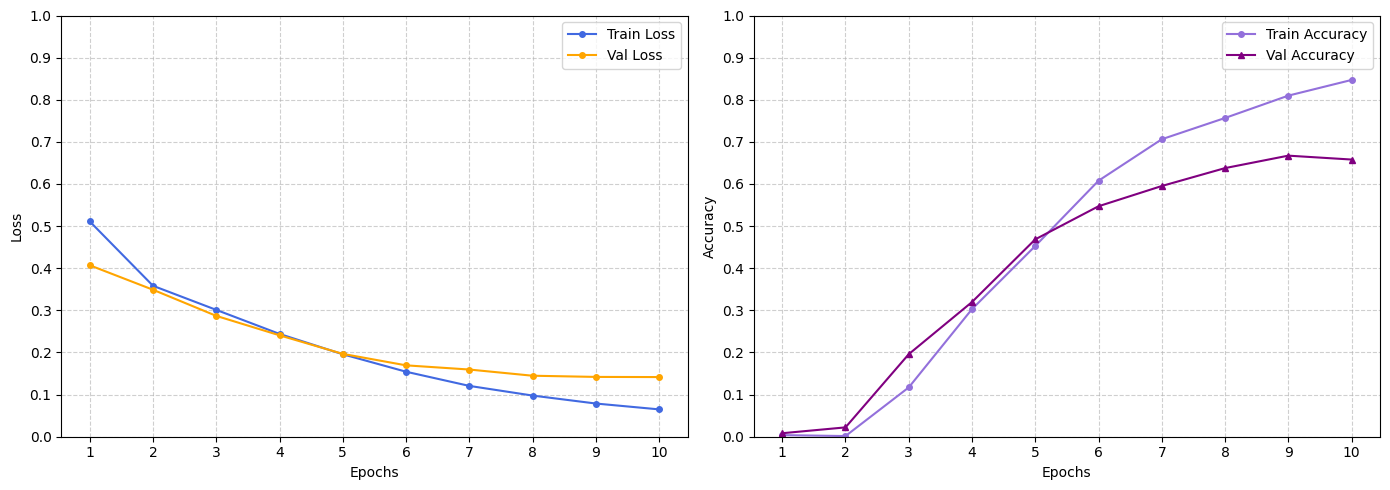

📊 [ResNet50 최종 결산] 클래스별 Support 비율 및 실제 정답 기준 신뢰도 대조표
  Class Support Ratio (정답 데이터 비율) True Avg Confidence (정답 기준 신뢰도)
Class 0                   11.55 %                         70.80 %
Class 1                    6.10 %                         73.71 %
Class 2                   19.50 %                         79.21 %
Class 3                   17.47 %                         63.62 %
Class 4                    8.50 %                         69.38 %
Class 5                   15.80 %                         76.57 %
Class 6                   28.74 %                         84.04 %
Class 7                    9.15 %                         77.77 %
Class 8                    5.82 %                         96.74 %

✨ 실험 완료


In [ ]:
# 5. [실험 2] ResNet50 학습 기동
num_classes = 9

print("🚀 resnet50 모델")
model_res = timm.create_model('resnet50', pretrained=True, num_classes=num_classes)

criterion = nn.BCEWithLogitsLoss()
optimizer_res = optim.AdamW(model_res.parameters(), lr=1e-4)

# 벤치마크 가동
history_res = train_model_with_metrics(
    model_res, train_loader, val_loader, criterion, optimizer_res, num_epochs=100, patience=10
)

# 시각화
plot_experiment_results(history_res, "ResNet50", val_loader, model_res, DEVICE)

# 🧹 GPU 메모리 청소
del model_res, optimizer_res
gc.collect()
torch.cuda.empty_cache()
print("✨ 실험 완료")

🚀 swin_tiny_patch4_window7_224 모델


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]


🔥 GPU Warm-up 진행 중...
✅ Warm-up 완료



Epoch 1 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 1 [Val]:   0%|          | 0/34 [00:00<?, ?it/s]

...

Epoch 12 [Val]:   0%|          | 0/34 [00:00<?, ?it/s]


▶️ [Epoch 12 결산]
  - Loss       | Train Loss: 0.0065  /  Val Loss: 0.1763
  - Accuracy   | 🌟 Train Acc: 0.9836  /  Val Acc: 0.7329
  - Metrics    | mAP: 91.94%  /  Macro F1: 0.8507  /  Prec: 0.8686  /  Rec: 0.8413
  - Hardware   | ⏱️ 소요 시간: 65.59초
⚠️ 과적합 경고: 9 / 10
--------------------------------------------------------------------------------


Epoch 13 [Train]:   0%|          | 0/100 [00:00<?, ?it/s]

Epoch 13 [Val]:   0%|          | 0/34 [00:00<?, ?it/s]


▶️ [Epoch 13 결산]
  - Loss       | Train Loss: 0.0063  /  Val Loss: 0.1715
  - Accuracy   | 🌟 Train Acc: 0.9867  /  Val Acc: 0.7366
  - Metrics    | mAP: 91.49%  /  Macro F1: 0.8529  /  Prec: 0.8675  /  Rec: 0.8410
  - Hardware   | ⏱️ 소요 시간: 66.62초
⚠️ 과적합 경고: 10 / 10
🛑 10회 연속 성능 개선 실패로 조기 종료

🏆 최적의 가중치 복원 완료

📊 실험 최종 결과
  - 에포크당 평균 순수 연산 시간: 65.90초
  - 최고 검증성능 최고점 (최저 Val Loss 시점) ➔ mAP: 92.13%
  - 🌟 최고점 시점 상세 지표 ➔ Accuracy: 0.7209 | Macro F1: 0.8432 | Precision: 0.8791 | Recall: 0.8221


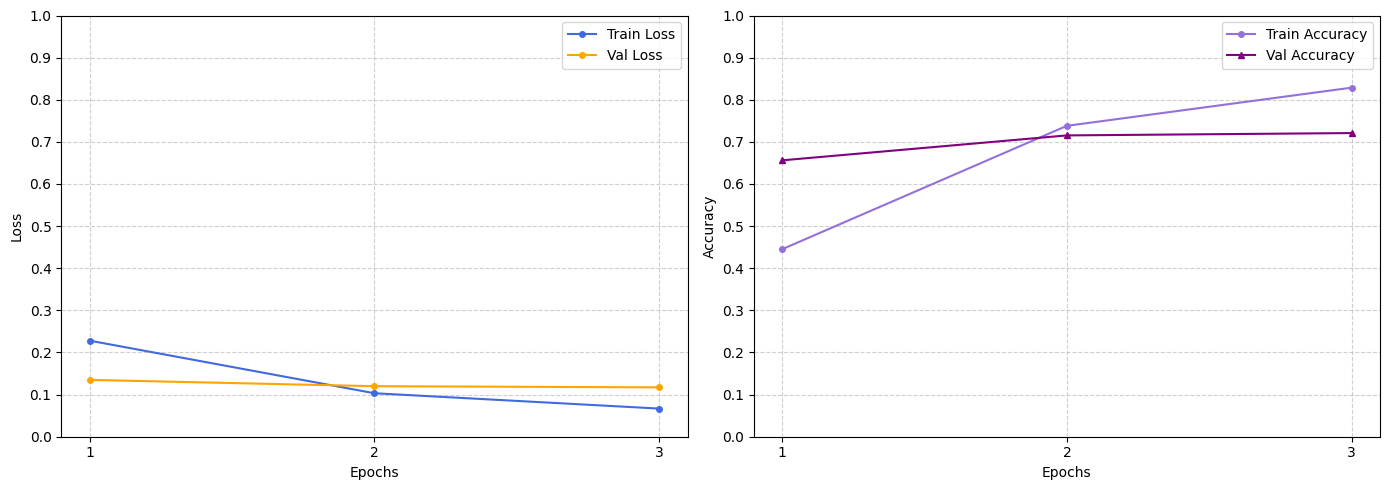

📊 [Swin-Tiny 최종 결산] 클래스별 Support 비율 및 실제 정답 기준 신뢰도 대조표
  Class Support Ratio (정답 데이터 비율) True Avg Confidence (정답 기준 신뢰도)
Class 0                   11.55 %                         90.34 %
Class 1                    6.10 %                         72.87 %
Class 2                   19.50 %                         82.88 %
Class 3                   17.47 %                         78.62 %
Class 4                    8.50 %                         73.91 %
Class 5                   15.80 %                         80.84 %
Class 6                   28.74 %                         92.18 %
Class 7                    9.15 %                         87.40 %
Class 8                    5.82 %                         94.73 %

✨ 실험 완료


In [ ]:
# 6. [실험 3] Swin-Tiny 트랜스포머 학습
num_classes = 9

print("🚀 swin_tiny_patch4_window7_224 모델")
model_swin = timm.create_model('swin_tiny_patch4_window7_224', pretrained=True, num_classes=num_classes)

criterion = nn.BCEWithLogitsLoss()
optimizer_swin = optim.AdamW(model_swin.parameters(), lr=1e-4)

# 벤치마크 가동
history_swin = train_model_with_metrics(
    model_swin, train_loader, val_loader, criterion, optimizer_swin, num_epochs=100, patience=10
)

# 시각화
plot_experiment_results(history_swin, "Swin-Tiny", val_loader, model_swin, DEVICE)

# 🧹 GPU 메모리 청소
del model_swin, optimizer_swin
gc.collect()
torch.cuda.empty_cache()
print("✨ 실험 완료")

In [ ]:
# onnx2tf와 텐서플로우가 동시에 만족하는 황금 밸런스 버전으로 강제 변경
!pip install "numpy==1.26.4" --force-reinstall

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 62.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
shap 0.51.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
jax 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
pytensor 2.38.3 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires 

In [ ]:
!nvidia-smi

Tue Jun  2 18:30:17 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   69C    P0             31W /   70W |    8249MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----